# Imports

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
seaborn_custom_params = {'axes.spines.right': False, 'axes.spines.top': False}
sns.set_theme(context = 'notebook', style ='white', rc=seaborn_custom_params)

In [2]:
project_path = Path.cwd()
project_data_sources_path = project_path / 'data' / 'sources'
project_data_exports_path = project_path / 'data' / 'exports'

print(project_path)
print(project_data_sources_path)
print(project_data_exports_path)

/Users/chrisizenour/Library/CloudStorage/Dropbox/phd/courses/ie_6683_machine_learning_with_industrial_engineering_applications/python_projects
/Users/chrisizenour/Library/CloudStorage/Dropbox/phd/courses/ie_6683_machine_learning_with_industrial_engineering_applications/python_projects/data/sources
/Users/chrisizenour/Library/CloudStorage/Dropbox/phd/courses/ie_6683_machine_learning_with_industrial_engineering_applications/python_projects/data/exports


# User Defined Functions

## Load Modeling Table

In [3]:
def load_modeling_table_dataset():
    df = pd.read_csv(
        project_data_exports_path / 'model_table.csv',
        # usecols=range(58),
        # sheet_name='Sheet1',
        # header=1,
        # engine='openpyxl',
    )
    # df = df.iloc[:-2]
    print(f'Shape of dataframe: {df.shape[0]} rows, {df.shape[1]} columns')
    return df

## Summary Stats Functionality

In [4]:
def summary_stats_df(df, cols):
    summary_stats_results = {}
    for col in cols:
        if df[col].nunique() == 1 and df[col].iloc[0] == 0:  # Handle all-zero columns
            summary_stats_results[col] = [df[col].count(), 0, 0, 0, 0, 0, 0, 0, 0]
        else:
            stats = df[col].agg(['count', 'mean', 'std', 'min', 'var', 'median'])
            quartiles = df[col].quantile([0.25, 0.75])
            summary_stats_results[col] = [
                stats['count'],
                stats['mean'],
                stats['std'],
                stats['min'],
                quartiles[0.25],
                stats['median'],
                quartiles[0.75],
                df[col].max(),
                stats['var']
            ]

    summary_stats_results_df = pd.DataFrame(
        summary_stats_results,
        index=['count', 'mean', 'std', 'min', '25%', 'median', '75%', 'max', 'variance']
    )

    return summary_stats_results_df


In [5]:
def categorical_summary_df(df, cols):
    summary_results = {}

    for col in cols:
        value_counts = df[col].value_counts(dropna=False)
        top_value = value_counts.idxmax()
        top_freq = value_counts.max()
        summary_results[col] = {
            'count': df[col].count(),
            'nunique': df[col].nunique(dropna=False),
            'most_frequent': top_value,
            'freq': top_freq,
            'top_5': value_counts.head(5).to_dict()
        }

    return pd.DataFrame(summary_results).T

## Corr and P-val Analysis

In [6]:
def correlation_matrix(df):
    """create correlation matrix dataframe"""
    df_corr_mat = df.corr()
    return df_corr_mat

In [7]:
def correlation_series(df):
    """create a dataframe which has unique feature pairs and their associated correlation coefficient"""
    upper_corr_mat = df.where(np.triu(np.ones(df.shape), k=1).astype(bool))
    unique_corr_pairs = upper_corr_mat.unstack().dropna()
    df_corr_series = unique_corr_pairs.sort_values(ascending=False)
    df_corr_series = df_corr_series.reset_index()
    df_corr_series = df_corr_series.rename(columns={
        'level_0': 'feature_1',
        'level_1': 'feature_2',
        0: 'correlation_coefficient'
    })
    return df_corr_series

In [8]:
def correlation_plot(df, title='Correlation Heatmap'):
    """create a correlation heatmap plot using seaborn"""
    mask = np.triu(np.ones_like(df, dtype=bool))
    f, ax = plt.subplots(1, 1, figsize=(11,9), facecolor='white')
    cmap = sns.diverging_palette(230, 20, as_cmap=True)
    sns.heatmap(df,
                mask=mask,
                cmap=cmap,
                vmax=1,
                vmin=-1,
                center=0,
                annot=False,
                square=True,
                linewidths=0.5,
                cbar_kws={'shrink': 0.5})
    ax.set_title(title)
    ax.set_xlabel('Variables')
    ax.set_ylabel('Variables')

    plt.tight_layout()
    return f

In [9]:
def p_val_matrix(df):
    """create p-value matrix dataframe"""
    df_p_val_mat = df.corr(method=lambda x, y: stats.pearsonr(x, y)[1]) - np.eye(len(df.columns))
    return df_p_val_mat

In [10]:
def p_val_series(df):
    """create a dataframe which has unique feature pairs and their associated level of statistical significance"""
    upper_corr_mat = df.where(np.triu(np.ones(df.shape), k=1).astype(bool))
    unique_p_val_pairs = upper_corr_mat.unstack().dropna()
    df_p_val_series = unique_p_val_pairs.sort_values()
    df_p_val_series = df_p_val_series.reset_index()
    df_p_val_series = df_p_val_series.rename(columns={
        'level_0': 'feature_1',
        'level_1': 'feature_2',
        0: 'p_value'
    })
    return df_p_val_series

In [11]:
def p_val_plot(df, title="P-value Heatmap (Green: Significant, White: Not Significant)"):
    """create a level of statistical significance heatmap plot using seaborn"""
    alpha = 0.05
    mask = np.triu(np.ones_like(df, dtype=bool))
    f, ax = plt.subplots(1, 1, figsize=(11,9))
    green = sns.light_palette('seagreen', reverse=True, as_cmap=True)
    green.set_over('white')
    # cmap = sns.diverging_palette(230, 20, as_cmap=True)
    sns.heatmap(df,
                mask=mask,
                cmap=green,
                # cmap=cmap,
                vmax=alpha,
                vmin=0,
                # center=0,
                annot=False,
                square=True,
                linewidths=0.5,
                cbar_kws={'shrink': 0.5})
    ax.set_title(title)
    ax.set_xlabel('Variables')
    ax.set_ylabel('Variables')
    plt.tight_layout()
    return f

# Load Dataset(s)

In [12]:
df = load_modeling_table_dataset()
df['index'] = df.index
df['season'] = pd.Categorical(df['season'], ordered=True, categories = [int(i) for i in range(2014, 2026)])
df['week'] = pd.Categorical(df['week'], ordered=True, categories = [int(i) for i in range(2, 17)])
df = df.drop(['overall_avg_diff', 'overall_points_diff', 'transfer_avg_diff', 'transfer_points_diff'], axis=1)
df

Shape of dataframe: 3304 rows, 47 columns


,season,week,date,away,home,neutral,conference_game,ranked_home,ranked_away,both_ranked,...,opp_rush_matchup_diff,opp_ypp_matchup_diff,home_pre_overall_avg_missing,home_pre_transfer_avg_missing,away_pre_overall_avg_missing,away_pre_transfer_avg_missing,avg_games_played_pre,season_phase,rank_status,index
0,2014,3,2014-09-13,georgia,south carolina,0,1,1,1,1,...,159.000000,-0.017941,1,1,1,1,1.0,early,away_higher_ranked,0
1,2014,3,2014-09-13,louisville,virginia,0,1,0,1,0,...,14.000000,-0.171715,1,1,1,1,1.0,early,away_higher_ranked,1
2,2014,3,2014-09-13,penn state,rutgers,0,1,0,0,0,...,51.000000,-0.872381,1,1,1,1,1.0,early,both_unranked,2
3,2014,3,2014-09-13,ucla,texas,1,0,0,1,0,...,-132.000000,0.029110,1,1,1,1,1.0,early,away_higher_ranked,3
4,2014,3,2014-09-13,usc,boston college,0,0,0,1,0,...,-147.000000,-0.898783,1,1,1,1,1.0,early,away_higher_ranked,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3299,2025,14,2025-11-29,wisconsin,minnesota,0,1,0,0,0,...,-34.777778,-2.261528,0,0,0,0,9.0,late,both_unranked,3299
3300,2025,15,2025-12-06,byu,texas tech,1,1,1,1,1,...,100.955556,1.543961,0,0,0,0,9.5,late,home_higher_ranked,3300
3301,2025,15,2025-12-06,duke,virginia,1,1,1,0,0,...,9.433333,1.063331,0,0,0,0,9.5,late,home_higher_ranked,3301
3302,2025,15,2025-12-06,georgia,alabama,1,1,1,1,1,...,46.388889,0.473197,0,0,0,0,9.5,late,away_higher_ranked,3302


In [13]:
distinct_away_teams = (
    df['away'].unique()
)
distinct_home_teams = (
    df['home'].unique()
)

print(f'distinct_away_teams: {len(distinct_away_teams)}')
print(f'distinct_home_teams: {len(distinct_home_teams)}')

# Values in arr1 not in arr2
diff1 = pd.Index(distinct_home_teams).difference(pd.Index(distinct_away_teams))
print(diff1)

diff2 = pd.Index(distinct_away_teams).difference(pd.Index(distinct_home_teams))
print(diff2)

distinct_away_teams: 69
distinct_home_teams: 69
Index([], dtype='object')
Index([], dtype='object')


# Interesting Groupbys

In [14]:
df.isnull().sum()

season                                   0
week                                     0
date                                     0
away                                     0
home                                     0
neutral                                  0
conference_game                          0
ranked_home                              0
ranked_away                              0
both_ranked                              0
margin_home                              0
home_win                                 0
home_pre_games_played_pre                0
away_pre_games_played_pre                0
rank_advantage_home                      0
win_pct_diff                             0
margin_pre_mean_diff                     0
margin_pre_last3_diff                    0
recruiting_avg_4yr_diff                  0
recruiting_points_mean_4yr_diff          0
points_for_pre_mean_diff                 0
points_against_pre_mean_diff             0
ypp_for_pre_mean_diff                    0
ypp_against

In [15]:
df['week'].value_counts(dropna=False)

week
13    349
10    328
11    323
9     319
12    308
6     299
7     298
8     297
5     274
4     194
14    193
3      64
15     39
16     14
2       5
Name: count, dtype: int64

In [16]:
df.groupby(['season'], observed=True).agg({'index': 'count'})

,index
season,
2014,272
2015,269
2016,282
2017,278
2018,278
2019,276
2020,222
2021,282
2022,279


In [17]:
df['home_win'].value_counts(normalize=True)

home_win
1    0.557203
0    0.442797
Name: proportion, dtype: float64

In [18]:
season_home_team_win_rate_df = df.groupby('season', observed=True).agg({'home_win': 'mean'})
season_home_team_win_rate_df.to_csv(project_data_exports_path / 'season_home_team_win_rate_df.csv')
season_home_team_win_rate_df

,home_win
season,
2014,0.492647
2015,0.565056
2016,0.553191
2017,0.564748
2018,0.571942
2019,0.565217
2020,0.549550
2021,0.574468
2022,0.555556


In [19]:
home_win_by_season_rank = (
    df.groupby(['season', 'rank_status'], observed=True).agg({'home_win': 'mean'}).reset_index()
)

home_win_by_season_rank

,season,rank_status,home_win
0,2014,away_higher_ranked,0.246914
1,2014,both_unranked,0.464912
2,2014,home_higher_ranked,0.792208
3,2015,away_higher_ranked,0.283582
4,2015,both_unranked,0.572650
5,2015,home_higher_ranked,0.776471
6,2016,away_higher_ranked,0.309524
7,2016,both_unranked,0.572581
8,2016,home_higher_ranked,0.797297
9,2017,away_higher_ranked,0.325581


In [20]:
home_win_by_season_rank_wide_df = (
    df.groupby(['season', 'rank_status'], observed=True).agg({'home_win': 'mean'}).unstack()
)

home_win_by_season_rank_wide_df.to_csv(project_data_exports_path / 'home_win_by_season_rank_wide_df.csv')
home_win_by_season_rank_wide_df

home_win                                 
rank_status away_higher_ranked both_unranked home_higher_ranked
season                                                         
2014                  0.246914      0.464912           0.792208
2015                  0.283582      0.572650           0.776471
2016                  0.309524      0.572581           0.797297
2017                  0.325581      0.549180           0.885714
2018                  0.341463      0.547826           0.839506
2019                  0.300000      0.537190           0.893333
2020                  0.250000      0.547170           0.796875
2021                  0.412500      0.523077           0.847222
2022                  0.390244      0.550000           0.740260
2023                  0.215190      0.551181           0.882353
2024                  0.371795      0.565891           0.802469
2025                  0.288889      0.612069           0.765432

In [21]:
home_win_by_conf_df = df.groupby(['conference_game'], observed=True).agg({'home_win': 'mean'})
home_win_by_conf_df.to_csv(project_data_exports_path / 'home_win_by_conf_df.csv')
home_win_by_conf_df

,home_win
conference_game,
0,0.555024
1,0.557351


In [22]:
home_win_by_season_conf_df = df.groupby(['season', 'conference_game'], observed=True).agg({'home_win': 'mean'})
home_win_by_season_conf_df.to_csv(project_data_exports_path / 'home_win_by_season_conf_df.csv')
home_win_by_season_conf_df

home_win
season conference_game          
2014   0                0.545455
       1                0.488000
2015   0                0.631579
       1                0.560000
2016   0                0.473684
       1                0.558935
2017   0                0.466667
       1                0.570342
2018   0                0.600000
       1                0.569767
2019   0                0.555556
       1                0.565891
2020   1                0.549550
2021   0                0.428571
       1                0.586207
2022   0                0.578947
       1                0.553846
2023   0                0.578947
       1                0.555147
2024   0                0.666667
       1                0.574074
2025   0                0.578947
       1                0.552239

In [23]:
df.groupby(['season'], observed=True).agg({'recruiting_avg_4yr_diff': 'mean'})

,recruiting_avg_4yr_diff
season,
2014,-0.153447
2015,0.204229
2016,0.038076
2017,0.026025
2018,0.065171
2019,0.075245
2020,-0.013266
2021,0.077598
2022,0.131810


# Define Feature Sets

In [24]:
summary_stat_num_cols = [
    'margin_home',
    'home_win',
    'neutral',
    'conference_game',
    'ranked_home',
    'ranked_away',
    'both_ranked',
    'home_pre_games_played_pre',
    'away_pre_games_played_pre',
    'rank_advantage_home',
    'win_pct_diff',
    'margin_pre_mean_diff',
    'margin_pre_last3_diff',
    'recruiting_avg_4yr_diff',
    'recruiting_points_mean_4yr_diff',
    'points_for_pre_mean_diff',
    'points_against_pre_mean_diff',
    'ypp_for_pre_mean_diff',
    'ypp_against_pre_mean_diff',
    'yppa_for_pre_mean_diff',
    'ypra_for_pre_mean_diff',
    'turnover_margin_pre_mean_diff',
    'third_down_rate_for_pre_mean_diff',
    'third_down_rate_against_pre_mean_diff',
    'possession_for_pre_mean_diff',
    'pass_matchup_diff',
    'rush_matchup_diff',
    'ypp_matchup_diff',
    'opp_pass_matchup_diff',
    'opp_rush_matchup_diff',
    'opp_ypp_matchup_diff',
]

In [25]:
summary_stat_cat_cols = [
    'season',
    'week',
    'away',
    'home']

In [26]:
corr_cols = [
    'season',
    'week',
    'margin_home',
    'home_win',
    'neutral',
    'conference_game',
    'ranked_home',
    'ranked_away',
    'both_ranked',
    'home_pre_games_played_pre',
    'away_pre_games_played_pre',
    'rank_advantage_home',
    'win_pct_diff',
    'margin_pre_mean_diff',
    'margin_pre_last3_diff',
    'recruiting_avg_4yr_diff',
    'recruiting_points_mean_4yr_diff',
    'points_for_pre_mean_diff',
    'points_against_pre_mean_diff',
    'ypp_for_pre_mean_diff',
    'ypp_against_pre_mean_diff',
    'yppa_for_pre_mean_diff',
    'ypra_for_pre_mean_diff',
    'turnover_margin_pre_mean_diff',
    'third_down_rate_for_pre_mean_diff',
    'third_down_rate_against_pre_mean_diff',
    'possession_for_pre_mean_diff',
    'pass_matchup_diff',
    'rush_matchup_diff',
    'ypp_matchup_diff',
    'opp_pass_matchup_diff',
    'opp_rush_matchup_diff',
    'opp_ypp_matchup_diff',
]

In [27]:
context_features = [
    "neutral",
    "conference_game",
    "ranked_home",
    "ranked_away",
    "both_ranked",
    "home_pre_games_played_pre",
    "away_pre_games_played_pre",
    "rank_advantage_home",
]

In [28]:
talent_features = [
    "recruiting_avg_4yr_diff",
    "recruiting_points_mean_4yr_diff",
    # "overall_avg_diff",
    # "overall_points_diff",
    # "transfer_avg_diff",
    # "transfer_points_diff",
    # "home_pre_overall_avg_missing",
    # "home_pre_transfer_avg_missing",
    # "away_pre_overall_avg_missing",
    # "away_pre_transfer_avg_missing",
]


In [29]:
performance_features = [
    "win_pct_diff",
    "margin_pre_mean_diff",
    "margin_pre_last3_diff",
    "points_for_pre_mean_diff",
    "points_against_pre_mean_diff",
    "ypp_for_pre_mean_diff",
    "ypp_against_pre_mean_diff",
    "yppa_for_pre_mean_diff",
    "ypra_for_pre_mean_diff",
    "turnover_margin_pre_mean_diff",
    "third_down_rate_for_pre_mean_diff",
    "third_down_rate_against_pre_mean_diff",
    "possession_for_pre_mean_diff",
]

In [30]:
matchup_features = [
    "pass_matchup_diff",
    "rush_matchup_diff",
    "ypp_matchup_diff",
    "opp_pass_matchup_diff",
    "opp_rush_matchup_diff",
    "opp_ypp_matchup_diff",
]

In [31]:
feature_sets = {
    "baseline": context_features,
    "baseline_matchup": context_features + matchup_features,
    "baseline_talent": context_features + talent_features,
    "baseline_performance": context_features + performance_features,
    "baseline_talent_performance": context_features + talent_features + performance_features,
    "full": context_features + talent_features + performance_features + matchup_features,
}


for name, cols in feature_sets.items():
    print(name, len(cols))

baseline 8
baseline_matchup 14
baseline_talent 10
baseline_performance 21
baseline_talent_performance 23
full 29


# Summary Stats

In [32]:
summary_stats_num_cols_df = summary_stats_df(df, summary_stat_num_cols)
summary_stats_num_cols_df

,margin_home,home_win,neutral,conference_game,ranked_home,ranked_away,both_ranked,home_pre_games_played_pre,away_pre_games_played_pre,rank_advantage_home,...,turnover_margin_pre_mean_diff,third_down_rate_for_pre_mean_diff,third_down_rate_against_pre_mean_diff,possession_for_pre_mean_diff,pass_matchup_diff,rush_matchup_diff,ypp_matchup_diff,opp_pass_matchup_diff,opp_rush_matchup_diff,opp_ypp_matchup_diff
count,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,...,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000,3304.000000
mean,2.601695,0.557203,0.033898,0.936743,0.347155,0.347155,0.130448,4.920702,4.896489,-0.050242,...,-0.008306,-0.001307,0.001199,-0.023702,1.129196,3.016674,0.046584,0.386353,1.586445,0.018703
std,20.422185,0.496792,0.180995,0.243461,0.476138,0.476138,0.336847,2.522993,2.515745,649.792666,...,1.491771,0.122784,0.121938,4.106970,83.918824,79.847979,1.366598,84.033921,77.956690,1.326126
min,-78.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,-998.000000,...,-8.000000,-0.600000,-0.474116,-17.080000,-473.000000,-524.000000,-6.185516,-380.000000,-358.833333,-5.948115
25%,-9.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,3.000000,3.000000,-7.250000,...,-0.987500,-0.075639,-0.075212,-2.598968,-52.729167,-46.861607,-0.831892,-54.143750,-48.000000,-0.838317
median,3.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,5.000000,5.000000,0.000000,...,0.000000,-0.001916,-0.001203,0.032857,-0.780556,3.000000,0.017424,-1.142857,1.500000,0.024821
75%,17.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,7.000000,7.000000,6.000000,...,0.875000,0.075363,0.078251,2.531518,54.517857,51.508929,0.915802,52.578571,49.854167,0.849769
max,66.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12.000000,11.000000,998.000000,...,9.000000,0.638889,0.559524,21.450000,442.000000,387.000000,5.790716,371.750000,299.400000,6.193823
variance,417.065647,0.246802,0.032759,0.059273,0.226707,0.226707,0.113466,6.365493,6.328973,422230.508526,...,2.225381,0.015076,0.014869,16.867202,7042.369044,6375.699781,1.867590,7061.699874,6077.245591,1.758610


In [33]:
categorical_summary_df(df, summary_stat_cat_cols)

,count,nunique,most_frequent,freq,top_5
season,3304,12,2023,291,"{2023: 291, 2024: 288, 2025: 287, 2016: 282, 2..."
week,3304,15,13,349,"{13: 349, 10: 328, 11: 323, 9: 319, 12: 308}"
away,3304,69,georgia,56,"{'georgia': 56, 'purdue': 56, 'clemson': 55, '..."
home,3304,69,clemson,56,"{'clemson': 56, 'washington': 55, 'stanford': ..."


# Correlations

In [34]:
corr_df = correlation_matrix(df[corr_cols])
corr_series_df = correlation_series(corr_df)
corr_series_df.to_csv(project_data_exports_path / 'corr_series_df.csv', index=False)
corr_series_df

,feature_1,feature_2,correlation_coefficient
0,recruiting_points_mean_4yr_diff,recruiting_avg_4yr_diff,0.976720
1,away_pre_games_played_pre,home_pre_games_played_pre,0.920679
2,margin_pre_last3_diff,margin_pre_mean_diff,0.917855
3,home_pre_games_played_pre,week,0.905665
4,away_pre_games_played_pre,week,0.899442
...,...,...,...
523,ypp_against_pre_mean_diff,margin_pre_mean_diff,-0.606646
524,points_against_pre_mean_diff,win_pct_diff,-0.635737
525,rank_advantage_home,ranked_away,-0.691636
526,points_against_pre_mean_diff,margin_pre_last3_diff,-0.701887


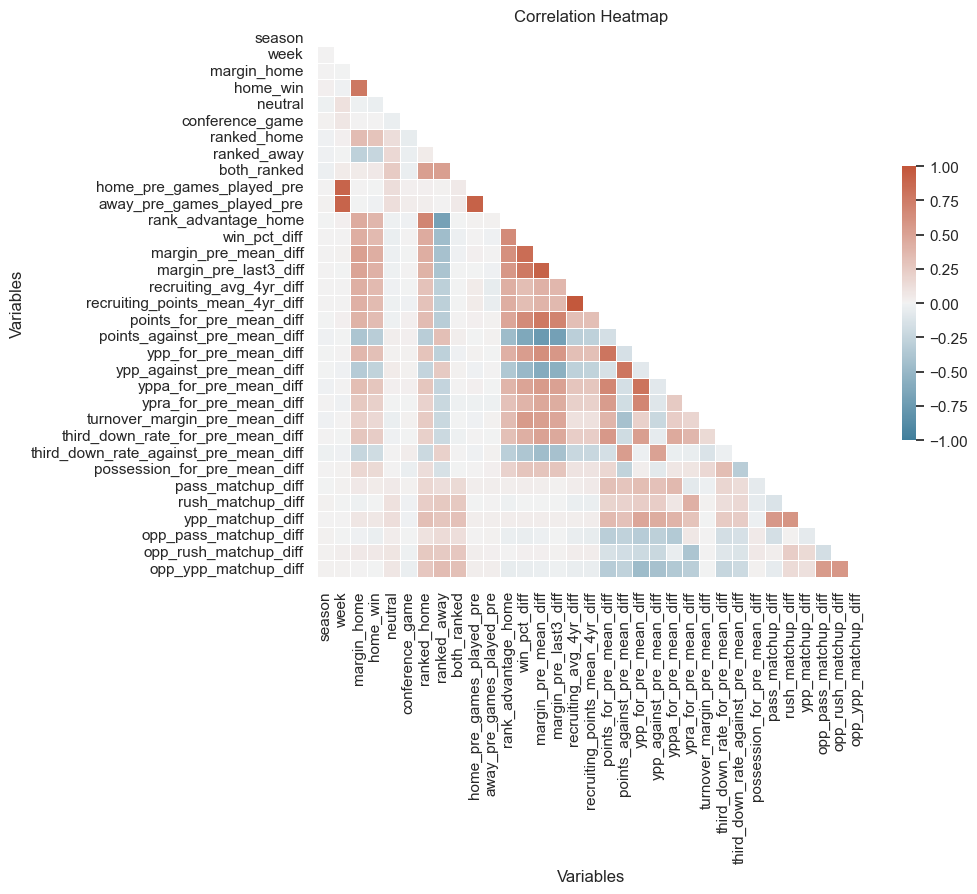

In [35]:
corr_heatmap = correlation_plot(corr_df)
corr_heatmap.savefig(project_data_exports_path / 'corr_heatmap.png', dpi=300, bbox_inches='tight')
corr_heatmap

In [36]:
pval_df = p_val_matrix(df[corr_cols])
pval_series_df = p_val_series(pval_df)
pval_series_df.to_csv(project_data_exports_path / 'pval_series_df.csv', index=False)
pval_series_df

,feature_1,feature_2,p_value
0,points_for_pre_mean_diff,margin_pre_mean_diff,0.000000
1,away_pre_games_played_pre,home_pre_games_played_pre,0.000000
2,rank_advantage_home,ranked_home,0.000000
3,rank_advantage_home,ranked_away,0.000000
4,win_pct_diff,rank_advantage_home,0.000000
...,...,...,...
523,third_down_rate_against_pre_mean_diff,neutral,0.988080
524,recruiting_points_mean_4yr_diff,both_ranked,0.989044
525,yppa_for_pre_mean_diff,away_pre_games_played_pre,0.991332
526,margin_pre_mean_diff,conference_game,0.993623


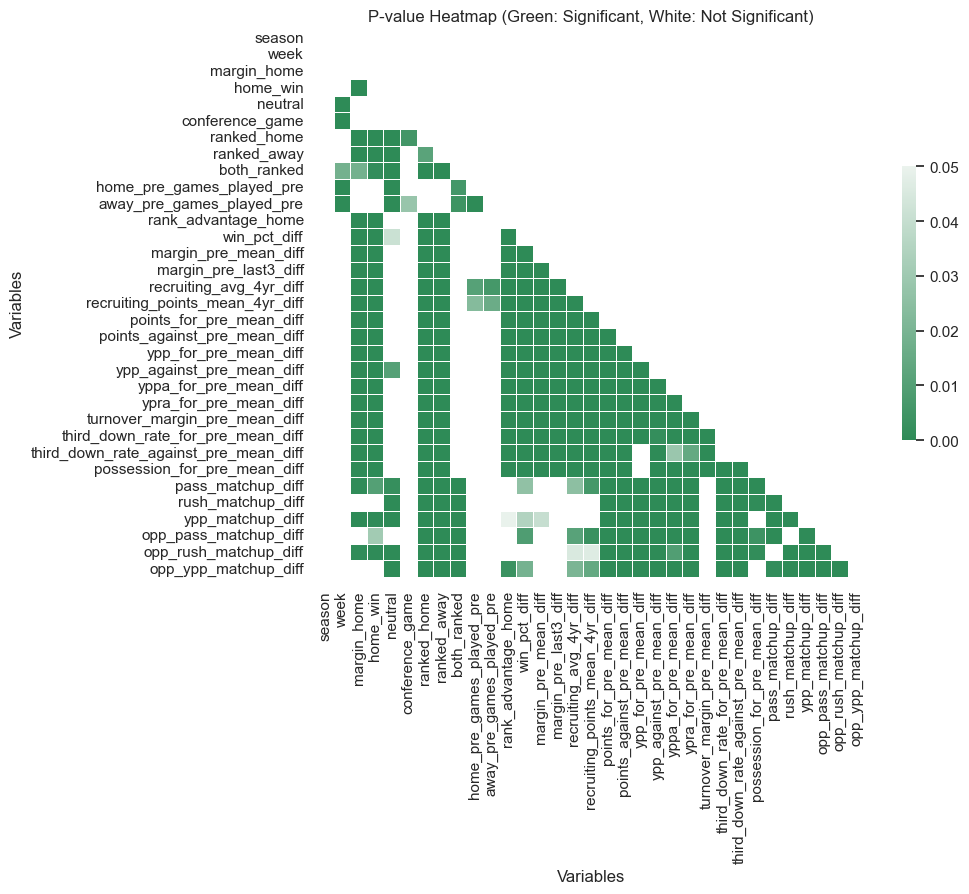

In [37]:
p_val_heatmap = p_val_plot(pval_df)
p_val_heatmap.savefig(project_data_exports_path / 'p_val_heatmap.png', dpi=300, bbox_inches='tight')
p_val_heatmap

In [38]:
corr_p_val_series_merged_df = pd.merge(corr_series_df, pval_series_df, on=['feature_1', 'feature_2'], how='inner').sort_values(by=['correlation_coefficient'], ascending=False)
corr_p_val_series_merged_df.to_csv(project_data_exports_path / 'corr_p_val_series_merged_df.csv', index=False)
corr_p_val_series_merged_df

,feature_1,feature_2,correlation_coefficient,p_value
0,recruiting_points_mean_4yr_diff,recruiting_avg_4yr_diff,0.976720,0.0
1,away_pre_games_played_pre,home_pre_games_played_pre,0.920679,0.0
2,margin_pre_last3_diff,margin_pre_mean_diff,0.917855,0.0
3,home_pre_games_played_pre,week,0.905665,0.0
4,away_pre_games_played_pre,week,0.899442,0.0
...,...,...,...,...
523,ypp_against_pre_mean_diff,margin_pre_mean_diff,-0.606646,0.0
524,points_against_pre_mean_diff,win_pct_diff,-0.635737,0.0
525,rank_advantage_home,ranked_away,-0.691636,0.0
526,points_against_pre_mean_diff,margin_pre_last3_diff,-0.701887,0.0
